In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
data = pd.read_csv("student_train.csv")

In [71]:
data.head()

,hours_studied,Sleep,Attendance,Previous,exam_score
0,8.0,8.8,72.1,45,30.2
1,1.3,8.6,60.7,55,25.0
2,4.0,8.2,73.7,86,35.8
3,3.5,4.8,95.1,66,34.0
4,9.1,6.4,89.8,71,40.3


In [72]:
data.isnull().sum()

hours_studied    0
Sleep            0
Attendance       0
Previous         0
exam_score       0
dtype: int64

In [73]:
data.duplicated().sum()

0

In [74]:
data.describe()


,hours_studied,Sleep,Attendance,Previous,exam_score
count,148.000000,148.000000,148.000000,148.000000,148.000000
mean,6.276351,6.684459,75.095270,67.033784,33.934459
std,3.250356,1.477114,14.833513,15.411549,6.719185
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.475000,5.400000,61.125000,54.000000,29.875000
50%,6.200000,6.700000,75.850000,67.500000,34.300000
75%,9.025000,8.100000,87.800000,80.000000,39.200000
max,12.000000,9.000000,100.000000,95.000000,47.900000


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hours_studied  148 non-null    float64
 1   Sleep          148 non-null    float64
 2   Attendance     148 non-null    float64
 3   Previous       148 non-null    int64  
 4   exam_score     148 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 5.9 KB


In [76]:
corr =data.corr()
corr["exam_score"].sort_values(ascending =False)

exam_score       1.000000
hours_studied    0.775168
Previous         0.361485
Attendance       0.300605
Sleep            0.214794
Name: exam_score, dtype: float64

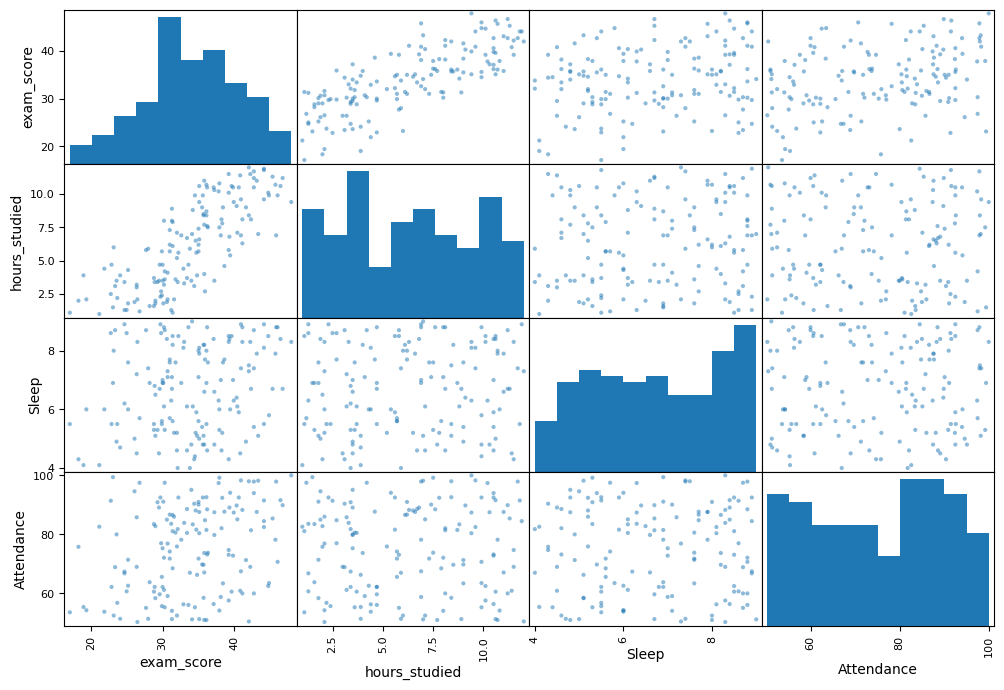

In [77]:
from pandas.plotting import scatter_matrix
attributes = ["exam_score","hours_studied" ,"Sleep","Attendance"]
scatter_matrix(data[attributes],figsize =(12,8))
plt.show()

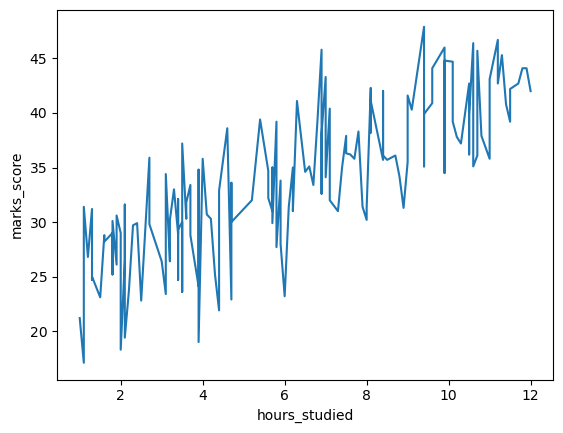

In [78]:
data_sorted = data.sort_values('hours_studied')
plt.plot(data_sorted['hours_studied'], data_sorted['exam_score'])
plt.xlabel("hours_studied")
plt.ylabel("marks_score")
plt.show()


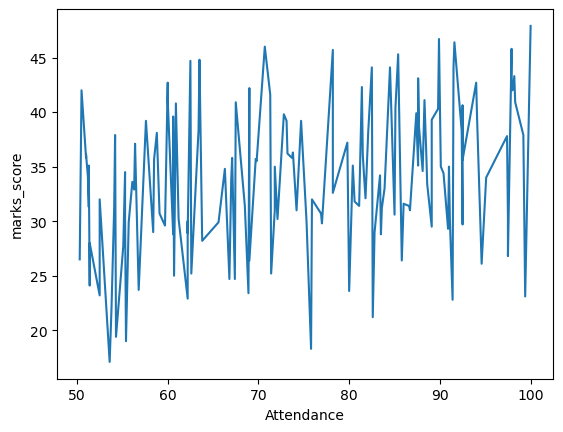

In [79]:
data_sorted = data.sort_values('Attendance')
plt.plot(data_sorted['Attendance'], data_sorted['exam_score'])
plt.xlabel("Attendance")
plt.ylabel("marks_score")
plt.show()


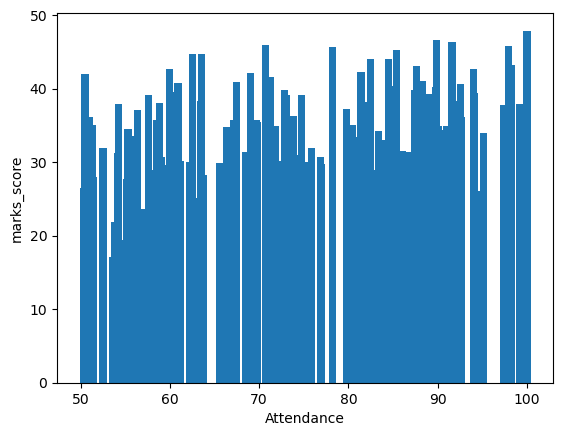

In [80]:
data_sorted = data.sort_values('Attendance')
plt.bar(data_sorted['Attendance'], data_sorted['exam_score'])
plt.xlabel("Attendance")
plt.ylabel("marks_score")
plt.show()


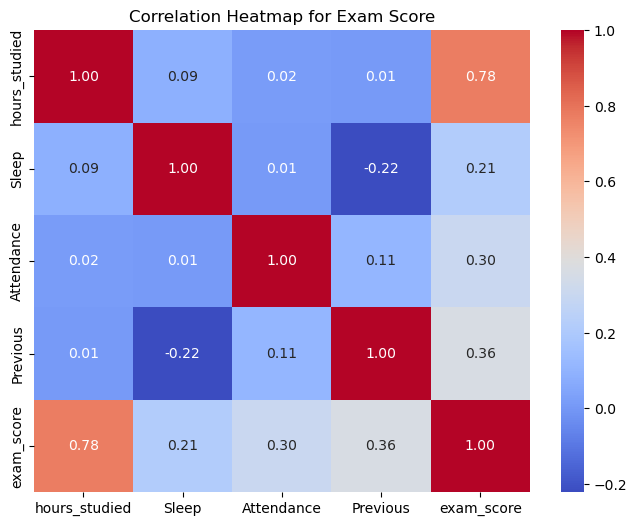

In [81]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap for Exam Score")
plt.show()


In [82]:
data["pre_score"] = pd.cut(data["Previous"],bins  =[35,45,55,65,75,85,95,100,np.inf], labels =[1,2,3,4,5,6,7,8])

In [83]:
from sklearn.model_selection import StratifiedShuffleSplit
split  = StratifiedShuffleSplit(n_splits= 1, test_size  =0.2, random_state =42)
for train_index , test_index in split.split(data,data["pre_score"]):
     strat_train_set =data.loc[train_index]
     strat_test_set =data.loc[test_index]
    
    
    
   


In [84]:
data.isna().sum()



hours_studied    0
Sleep            0
Attendance       0
Previous         0
exam_score       0
pre_score        0
dtype: int64

In [85]:
marks =strat_train_set.drop("exam_score" ,axis  =1)
marks_labels =strat_train_set["exam_score"].copy()

In [86]:
from sklearn.impute import SimpleImputer
imputer =SimpleImputer(strategy ="median")
marks_num = marks.select_dtypes(include  =[np.number])
x  = imputer.fit_transform(marks_num)


In [87]:
x

array([[  3.4,   6.2,  67.4,  70. ],
       [  7.8,   5.2,  92.4,  57. ],
       [  3.9,   4.7,  51.4,  44. ],
       [ 11.8,   5.5,  91.5,  74. ],
       [ 11.2,   6.7,  89.9,  59. ],
       [  3.7,   5.5,  60.6,  90. ],
       [  8.7,   6.9,  81.5,  55. ],
       [  6.2,   8. ,  91. ,  46. ],
       [  1. ,   4.1,  82.6,  54. ],
       [  7.7,   4.8,  51. ,  88. ],
       [  3.1,   4.3,  90.4,  80. ],
       [  1.5,   6.9,  99.4,  47. ],
       [  7. ,   9. ,  51.2,  41. ],
       [ 11.4,   4.5,  60.9,  67. ],
       [  1.8,   6.9,  91.1,  58. ],
       [  1.1,   8.5,  81.1,  92. ],
       [  3.4,   6.8,  62.2,  45. ],
       [  7.3,   7.6,  71.8,  54. ],
       [ 10.8,   6. ,  54.2,  88. ],
       [  8.4,   5.1,  58.5,  75. ],
       [  3.2,   7.2,  85.8,  50. ],
       [  2.4,   5.5,  55.7,  87. ],
       [  8. ,   7.1,  54.1,  75. ],
       [  3.7,   6.1,  80.5,  92. ],
       [  3. ,   4.5,  69. ,  59. ],
       [  2.1,   6. ,  54.3,  54. ],
       [ 10.6,   8.4,  91.6,  55. ],
 

In [88]:
from sklearn.preprocessing import StandardScaler
std =StandardScaler()
marks_std =std.fit_transform(marks_num)

In [89]:
marks_std

array([[-8.67093083e-01, -2.99884597e-01, -5.30455777e-01,
         1.92793636e-01],
       [ 4.93834150e-01, -9.86998818e-01,  1.11346117e+00,
        -6.47392267e-01],
       [-7.12442261e-01, -1.33055593e+00, -1.58256262e+00,
        -1.48757817e+00],
       [ 1.73104073e+00, -7.80864552e-01,  1.05428016e+00,
         4.51312375e-01],
       [ 1.54545974e+00,  4.36725141e-02,  9.49069475e-01,
        -5.18132897e-01],
       [-7.74302590e-01, -7.80864552e-01, -9.77601186e-01,
         1.48538733e+00],
       [ 7.72205630e-01,  1.81095358e-01,  3.96713381e-01,
        -7.76651636e-01],
       [-1.04848015e-03,  9.36921002e-01,  1.02140182e+00,
        -1.35831880e+00],
       [-1.60941703e+00, -1.74282446e+00,  4.69045727e-01,
        -8.41281321e-01],
       [ 4.62903986e-01, -1.26184451e+00, -1.60886529e+00,
         1.35612796e+00],
       [-9.59883576e-01, -1.60540162e+00,  9.81947814e-01,
         8.39090485e-01],
       [-1.45476621e+00,  1.81095358e-01,  1.57375791e+00,
      

In [90]:
from sklearn.pipeline import make_pipeline
pipeline  = make_pipeline(SimpleImputer(strategy ="median"),StandardScaler())
marks_num_prepared = pipeline.fit_transform(marks_num)

In [91]:
print(marks_num_prepared[:2].round(2))

[[-0.87 -0.3  -0.53  0.19]
 [ 0.49 -0.99  1.11 -0.65]]


In [92]:
data.head()

,hours_studied,Sleep,Attendance,Previous,exam_score,pre_score
0,8.0,8.8,72.1,45,30.2,1
1,1.3,8.6,60.7,55,25.0,2
2,4.0,8.2,73.7,86,35.8,6
3,3.5,4.8,95.1,66,34.0,4
4,9.1,6.4,89.8,71,40.3,4


In [93]:
marks_num.head()

,hours_studied,Sleep,Attendance,Previous
107,3.4,6.2,67.4,70
37,7.8,5.2,92.4,57
52,3.9,4.7,51.4,44
130,11.8,5.5,91.5,74
141,11.2,6.7,89.9,59


In [94]:
data_marks_num_prepared  =pd.DataFrame(
    marks_num_prepared,
    columns  = pipeline.get_feature_names_out(),
    index =marks_num.index
)

In [95]:
data_marks_num_prepared

,hours_studied,Sleep,Attendance,Previous
107,-0.867093,-0.299885,-0.530456,0.192794
37,0.493834,-0.986999,1.113461,-0.647392
52,-0.712442,-1.330556,-1.582563,-1.487578
130,1.731041,-0.780865,1.054280,0.451312
141,1.545460,0.043673,0.949069,-0.518133
...,...,...,...,...
53,0.586625,-1.399267,0.436167,0.580572
128,0.864996,0.662075,-0.793482,-0.001095
120,-0.001048,0.730787,0.738648,-0.712022
106,-0.836163,-1.467979,0.896464,0.709831


In [96]:
data.head()

    
   

,hours_studied,Sleep,Attendance,Previous,exam_score,pre_score
0,8.0,8.8,72.1,45,30.2,1
1,1.3,8.6,60.7,55,25.0,2
2,4.0,8.2,73.7,86,35.8,6
3,3.5,4.8,95.1,66,34.0,4
4,9.1,6.4,89.8,71,40.3,4


In [143]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
data = pd.read_csv("student_train.csv")
data["pre_score"] =pd.cut(data["Previous"], bins =[35,45,55,65,75,85,95,100,np.inf] , labels  = [1,2,3,4,5,6,7,8])
split = StratifiedShuffleSplit(n_splits =1 , test_size =0.2 , random_state = 42)
for train_index , test_index  in split.split(data,data["pre_score"]):
    strat_train_set = data.loc[train_index].drop("pre_score",axis =1)
    strat_test_set =data.loc[test_index].drop("exam_score", axis =1)

marks =strat_train_set.copy()
marks_labels = data["exam_score"].copy()
marks = data.drop("exam_score",axis =1)
marks_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

marks_prepared = marks_pipeline.fit_transform(marks)
print(marks_prepared.shape)    

(148, 5)


In [144]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
lin_reg = LinearRegression()
lin_reg.fit(marks_prepared, marks_labels)
tree_reg =DecisionTreeRegressor(random_state =42)
tree_reg.fit(marks_prepared, marks_labels)
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(marks_prepared, marks_labels)
lin_preds = lin_reg.predict(marks_prepared)
tree_preds = tree_reg.predict(marks_prepared)
forest_preds = forest_reg.predict(marks_prepared)
lin_rmse  = mean_squared_error(marks_labels, lin_preds , squared =False)
tree_rmse = mean_squared_error(marks_labels,tree_preds,squared  =False)
forest_rmse = mean_squared_error(marks_labels,forest_preds,squared  =False)




C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [145]:
print("Linear Regression RMSE:", lin_rmse)
print("Decision Tree RMSE:", tree_rmse)
print("Random Forest RMSE:", forest_rmse)

Linear Regression RMSE: 2.6070486559633697
Decision Tree RMSE: 0.0
Random Forest RMSE: 1.282154834749012


In [146]:
from sklearn.model_selection import cross_val_score
import pandas as pd
tree_rmse = -cross_val_score(
    tree_reg,
    marks_prepared,
    marks_labels,
    scoring  ="neg_root_mean_squared_error",
    cv  =10
)
print("Decison Tree CV rmse:",tree_rmse)
print("\nCross-Validation Performance (Decision Tree):")
print(pd.Series(tree_rmse).describe())

Decison Tree CV rmse: [5.73294572 3.60138862 4.85207859 3.9852227  3.78294418 5.06813575
 6.29280012 5.83049455 6.12675631 3.78738508]

Cross-Validation Performance (Decision Tree):
count    10.000000
mean      4.906015
std       1.056387
min       3.601389
25%       3.836844
50%       4.960107
75%       5.806107
max       6.292800
dtype: float64


In [162]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

S_Model = "S_model.pkl"
S_Pipeline = "S_pipeline.pkl"
COLS_FILE = "columns.pkl"

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

if not os.path.exists(S_Model) or not os.path.exists(S_Pipeline) or not os.path.exists(COLS_FILE):


    data = pd.read_csv("student_train.csv")

    # ---- Safety: remove invalid values for stratification
    data = data[data["Previous"] >= 35]

    data["pre_score"] = pd.cut(
        data["Previous"],
        bins=[35,45,55,65,75,85,95,100,np.inf],
        labels=[1,2,3,4,5,6,7,8]
    )

    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

    for train_index, _ in split.split(data, data["pre_score"]):
        strat_train_set = data.loc[train_index]

    strat_train_set = strat_train_set.drop("pre_score", axis=1)

    marks_labels = strat_train_set["exam_score"].copy()
    marks_features = strat_train_set.drop("exam_score", axis=1)

    # ---- Numeric safety
    marks_features = marks_features.apply(pd.to_numeric, errors="coerce")

    marks_features_prepared = num_pipeline.fit_transform(marks_features)

    model = RandomForestRegressor(random_state=42)
    model.fit(marks_features_prepared, marks_labels)

    joblib.dump(model, S_Model)
    joblib.dump(num_pipeline, S_Pipeline)
    joblib.dump(marks_features.columns.tolist(), COLS_FILE)

    print("Model trained and saved successfully")

else:

    model = joblib.load(S_Model)
    pipeline = joblib.load(S_Pipeline)
    cols = joblib.load(COLS_FILE)

    input_data = pd.read_csv("student_test.csv")

    # ---- Remove target if exists
    if "exam_score" in input_data.columns:
        input_data = input_data.drop("exam_score", axis=1)

    # ---- Align columns
    input_data = input_data[cols]

    # ---- Numeric safety
    input_data = input_data.apply(pd.to_numeric, errors="coerce")

    transformed_input = pipeline.transform(input_data)

    predictions = model.predict(transformed_input)
    input_data["exam_score"] = predictions

    input_data.to_csv(r"C:\Users\Kapil\Desktop\machine_learning\output1.csv", index=False)
    print("Saved to:", os.getcwd())

    print("Inference complete. Results saved to output1.csv")


Saved to: C:\Users\Kapil\Desktop\machine_learning
Inference complete. Results saved to output1.csv


In [163]:
import os
os.getcwd()


'C:\\Users\\Kapil\\Desktop\\machine_learning'

In [164]:
import os
os.listdir()


['.ipynb_checkpoints',
 '.virtual_documents',
 'columns.pkl',
 'Fraud.csv',
 'House_price_prediction_ml_model.ipynb',
 'house_related_Stuff.ipynb',
 'housing.csv',
 'ml1.pdf',
 'ml1_project.ipynb',
 'ml2.pdf',
 'ml3_notes.pdf',
 'model.pkl',
 'numpy_practice.ipynb',
 'output.csv',
 'output1.csv',
 'pipeline.pkl',
 'project3.ipynb',
 'student_score_prediction.ipynb',
 'student_test.csv',
 'student_train.csv',
 'S_model.pkl',
 'S_pipeline.pkl',
 'tempCodeRunnerFile.py',
 'tempCodeRunnerFile.python',
 'test_file.txt',
 'test_house - Copy.csv',
 'test_house.csv',
 'train_house.csv',
 'Untitled.ipynb']

In [161]:
import os

print("Current folder:", os.getcwd())
print("Files here:", os.listdir())


Current folder: C:\Users\Kapil\Desktop\machine_learning
Files here: ['.ipynb_checkpoints', '.virtual_documents', 'columns.pkl', 'Fraud.csv', 'House_price_prediction_ml_model.ipynb', 'house_related_Stuff.ipynb', 'housing.csv', 'ml1.pdf', 'ml1_project.ipynb', 'ml2.pdf', 'ml3_notes.pdf', 'model.pkl', 'numpy_practice.ipynb', 'output.csv', 'pipeline.pkl', 'project3.ipynb', 'student_score_prediction.ipynb', 'student_test.csv', 'student_train.csv', 'S_model.pkl', 'S_pipeline.pkl', 'tempCodeRunnerFile.py', 'tempCodeRunnerFile.python', 'test_file.txt', 'test_house - Copy.csv', 'test_house.csv', 'train_house.csv', 'Untitled.ipynb']
